# Fish + MiniRocketClassifier: untuned vs tuned comparison

In [11]:
from pathlib import Path
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import sys
import subprocess

## 1. General configuration

```text
window size: 10% → 50%
step: 1%
stride ratios: 0.1, 0.2, 0.5
metric: series_macro_f1
```


In [12]:
def find_repo_root(start_path: Path = Path.cwd()) -> Path:
    current = start_path.resolve()

    while current != current.parent:
        if (current / "scripts" / "run_experiment.py").exists():
            return current
        current = current.parent

    raise FileNotFoundError(
        "Could not find repository root containing scripts/run_experiment.py"
    )

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

print("Working directory:", Path.cwd())
assert Path("scripts/run_experiment.py").exists()

Working directory: /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow


In [13]:
assert Path("scripts/run_experiment.py").exists(), "Run the notebook from the Thesis_SlidingWindow repository root"

DATASET_FOLDER = "data/raw/Fish"
CLASSIFIER = "MiniRocketClassifier"

WINDOW_START = "0.10"
WINDOW_END = "0.50"
WINDOW_STEP = "0.01"

STRIDE_RATIOS = ["0.1", "0.2", "0.5"]

METRIC = "series_macro_f1"
N_TRIALS = "20"
RANDOM_STATE = "42"

NOT_TUNED_DIR = Path("results/Fish/noTuning/MiniRocket/notTuned_20_40")
TUNING_DIR = Path("results/Fish/tuning/Fish/MiniRocket/per_config_20_40")
TUNED_DIR = Path("results/Fish/tuned/MiniRocket/tunedBest_20_40")

COMPARISON_DIR = Path("results/Fish/MiniRocket/comparison_20_40")
PLOTS_DIR = Path("plots/Fish/MiniRocket/macro_f1_20_40")

for directory in [NOT_TUNED_DIR, TUNING_DIR, TUNED_DIR, COMPARISON_DIR, PLOTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET_FOLDER)
print("Classifier:", CLASSIFIER)
print("Window range:", WINDOW_START, WINDOW_END, WINDOW_STEP)
print("Stride ratios:", STRIDE_RATIOS)
print("Metric:", METRIC)
print("N trials:", N_TRIALS)


Dataset: data/raw/Fish
Classifier: MiniRocketClassifier
Window range: 0.10 0.50 0.01
Stride ratios: ['0.1', '0.2', '0.5']
Metric: series_macro_f1
N trials: 20


In [14]:
PYTHON_EXECUTABLE = sys.executable

def run_command(command: list[str]) -> None:
    command = command.copy()

    if command[0] == "python":
        command[0] = PYTHON_EXECUTABLE
        command.insert(1, "-u")  # unbuffered output

    print("\nRunning command:")
    print(" ".join(command))
    print()

    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"

    subprocess.run(
        command,
        check=True,
        env=env,
    )


## 3. Untuned run

Output:

```text
results/Fish/MiniRocket/notTuned_10_50/
```


In [15]:
run_command([
    "python", "scripts/run_experiment.py",
    "--dataset-folder", DATASET_FOLDER,
    "--classifier", CLASSIFIER,
    "--window-sizes", WINDOW_START, WINDOW_END, WINDOW_STEP,
    "--percentages",
    "--stride-ratios", *STRIDE_RATIOS,
    "--output-dir", str(NOT_TUNED_DIR),
    "--random-state", RANDOM_STATE,
])



Running command:
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python -u scripts/run_experiment.py --dataset-folder data/raw/Fish --classifier MiniRocketClassifier --window-sizes 0.10 0.50 0.01 --percentages --stride-ratios 0.1 0.2 0.5 --output-dir results/Fish/noTuning/MiniRocket/notTuned_20_40 --random-state 42



Fish / MiniRocketClassifier:  99%|█████████▉| 122/123 [38:40<00:01,  1.33s/config, status=ok, stride=46, stride_ratio=0.2, window_size=231] 


Results saved to: results/Fish/noTuning/MiniRocket/notTuned_20_40/Fish_MiniRocketClassifier_20260629_191628.csv


Fish / MiniRocketClassifier: 100%|██████████| 123/123 [38:40<00:00, 18.87s/config, status=ok, stride=115, stride_ratio=0.5, window_size=231]


## 4. Check untuned results


In [16]:
not_tuned_files = sorted(NOT_TUNED_DIR.glob("*.csv"))
assert not_tuned_files, f"No CSV files found in {NOT_TUNED_DIR}"

not_tuned_file = not_tuned_files[-1]
not_tuned = pd.read_csv(not_tuned_file)

print("Untuned file:", not_tuned_file)
print()
print("Status counts:")
print(not_tuned["status"].value_counts())
print()

display(not_tuned[[
    "dataset",
    "classifier",
    "window_size",
    "window_percentage",
    "stride_ratio",
    "series_macro_f1",
    "status",
    "error",
]].head(20))


Untuned file: results/Fish/noTuning/MiniRocket/notTuned_20_40/Fish_MiniRocketClassifier_20260629_191628.csv

Status counts:
status
ok    123
Name: count, dtype: int64



,dataset,classifier,window_size,window_percentage,stride_ratio,series_macro_f1,status,error
0,Fish,MiniRocketClassifier,46,0.099352,0.1,0.829736,ok,NaN
1,Fish,MiniRocketClassifier,46,0.099352,0.2,0.887278,ok,NaN
2,Fish,MiniRocketClassifier,46,0.099352,0.5,0.873257,ok,NaN
3,Fish,MiniRocketClassifier,50,0.107991,0.1,0.792968,ok,NaN
4,Fish,MiniRocketClassifier,50,0.107991,0.2,0.920395,ok,NaN
5,Fish,MiniRocketClassifier,50,0.107991,0.5,0.910344,ok,NaN
6,Fish,MiniRocketClassifier,55,0.118790,0.1,0.853221,ok,NaN
7,Fish,MiniRocketClassifier,55,0.118790,0.2,0.911507,ok,NaN
8,Fish,MiniRocketClassifier,55,0.118790,0.5,0.910109,ok,NaN
9,Fish,MiniRocketClassifier,60,0.129590,0.1,0.875111,ok,NaN


## 5. Tuning for each window/stride combination

This command searches for the best hyperparameters separately for each combination:

```text
window_size × stride_ratio
```

Main outputs:

```text
results/tuning/Fish/MiniRocket/per_config_10_50/best_hyperparameters/
results/tuning/Fish/MiniRocket/per_config_10_50/best_hyperparameters_index.csv
```

In [17]:
run_command([
    "python", "scripts/tune_per_configuration.py",
    "--dataset-folder", DATASET_FOLDER,
    "--classifier", CLASSIFIER,
    "--window-sizes", WINDOW_START, WINDOW_END, WINDOW_STEP,
    "--percentages",
    "--stride-ratios", *STRIDE_RATIOS,
    "--metric", METRIC,
    "--n-trials", N_TRIALS,
    "--output-dir", str(TUNING_DIR),
    "--random-state", RANDOM_STATE,
])



Running command:
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python -u scripts/tune_per_configuration.py --dataset-folder data/raw/Fish --classifier MiniRocketClassifier --window-sizes 0.10 0.50 0.01 --percentages --stride-ratios 0.1 0.2 0.5 --metric series_macro_f1 --n-trials 20 --output-dir results/Fish/tuning/Fish/MiniRocket/per_config_20_40 --random-state 42


[1/123] Tuning Fish / MiniRocketClassifier / window_size=46 / stride_ratio=0.1


[I 2026-06-29 19:16:30,694] A new study created in memory with name: no-name-91ec3dc6-950f-4b70-8dea-4e7fbf5d8713
Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:01<00:00,  1.39s/config, status=ok, stride=4, stride_ratio=0.1, window_size=46]
[I 2026-06-29 19:16:32,104] Trial 0 finished with value: 0.881417267218153 and parameters: {'n_kernels': 700, 'max_dilations_per_kernel': 16}. Best is trial 0 with value: 0.881417267218153.
Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:04<00:00,  4.91s/config, status=ok, stride=4, stride_ratio=0.1, window_size=46]
[I 2026-06-29 19:16:37,037] Trial 1 finished with value: 0.8787821988251634 and parameters: {'n_kernels': 1800, 'max_dilations_per_kernel': 16}. Best is trial 0 with value: 0.881417267218153.
Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:02<00:00,  2.91s/config, status=ok, stride=4, stride_ratio=0.1, window_size=46]
[I 2026-06-29 19:16:39,967] Trial 2 finished with value: 0.8992463306220367 and parameters: {'n_kernel


[2/123] Tuning Fish / MiniRocketClassifier / window_size=46 / stride_ratio=0.2


Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:06<00:00,  6.54s/config, status=ok, stride=9, stride_ratio=0.2, window_size=46]
[I 2026-06-29 19:18:11,109] Trial 0 finished with value: 0.8617045882680557 and parameters: {'n_kernels': 2650, 'max_dilations_per_kernel': 64}. Best is trial 0 with value: 0.8617045882680557.
Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:02<00:00,  2.97s/config, status=ok, stride=9, stride_ratio=0.2, window_size=46]
[I 2026-06-29 19:18:14,107] Trial 1 finished with value: 0.8337635850096007 and parameters: {'n_kernels': 1900, 'max_dilations_per_kernel': 16}. Best is trial 0 with value: 0.8617045882680557.
Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:06<00:00,  6.75s/config, status=ok, stride=9, stride_ratio=0.2, window_size=46]
[I 2026-06-29 19:18:20,884] Trial 2 finished with value: 0.8748655654861268 and parameters: {'n_kernels': 2800, 'max_dilations_per_kernel': 32}. Best is trial 2 with value: 0.8748655654861268.
Fish / MiniRocketCl


[3/123] Tuning Fish / MiniRocketClassifier / window_size=46 / stride_ratio=0.5


...


[122/123] Tuning Fish / MiniRocketClassifier / window_size=231 / stride_ratio=0.2


Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:00<00:00,  2.50config/s, status=ok, stride=46, stride_ratio=0.2, window_size=231]
[I 2026-06-29 20:15:57,976] Trial 0 finished with value: 0.9654012838290669 and parameters: {'n_kernels': 2150, 'max_dilations_per_kernel': 16}. Best is trial 0 with value: 0.9654012838290669.
Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:00<00:00,  4.50config/s, status=ok, stride=46, stride_ratio=0.2, window_size=231]
[I 2026-06-29 20:15:58,216] Trial 1 finished with value: 0.9538725660352759 and parameters: {'n_kernels': 850, 'max_dilations_per_kernel': 16}. Best is trial 0 with value: 0.9654012838290669.
Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:00<00:00,  2.23config/s, status=ok, stride=46, stride_ratio=0.2, window_size=231]
[I 2026-06-29 20:15:58,683] Trial 2 finished with value: 0.9888685782302804 and parameters: {'n_kernels': 2500, 'max_dilations_per_kernel': 64}. Best is trial 2 with value: 0.9888685782302804.
Fish / MiniRoc


[123/123] Tuning Fish / MiniRocketClassifier / window_size=231 / stride_ratio=0.5


Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:00<00:00,  5.47config/s, status=ok, stride=115, stride_ratio=0.5, window_size=231]
[I 2026-06-29 20:16:05,012] Trial 0 finished with value: 0.9519336257561214 and parameters: {'n_kernels': 2100, 'max_dilations_per_kernel': 64}. Best is trial 0 with value: 0.9519336257561214.
Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:00<00:00,  5.96config/s, status=ok, stride=115, stride_ratio=0.5, window_size=231]
[I 2026-06-29 20:16:05,198] Trial 1 finished with value: 0.9537664805060805 and parameters: {'n_kernels': 1950, 'max_dilations_per_kernel': 16}. Best is trial 1 with value: 0.9537664805060805.
Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:00<00:00, 12.40config/s, status=ok, stride=115, stride_ratio=0.5, window_size=231]
[I 2026-06-29 20:16:05,296] Trial 2 finished with value: 0.9410389156412441 and parameters: {'n_kernels': 550, 'max_dilations_per_kernel': 16}. Best is trial 1 with value: 0.9537664805060805.
Fish / Mini


Tuning completed.
Saved 123 best hyperparameter files.
Index file: results/Fish/tuning/Fish/MiniRocket/per_config_20_40/best_hyperparameters_index.csv


## 6. Check tuning


In [18]:
index_file = TUNING_DIR / "best_hyperparameters_index.csv"
assert index_file.exists(), f"Index file not found: {index_file}"

best_index = pd.read_csv(index_file)

print("Best hyperparameters index:", index_file)
print()
print("Best status counts:")
print(best_index["best_status"].value_counts(dropna=False))
print()

display(best_index[[
    "window_size",
    "window_percentage",
    "stride_ratio",
    "best_value",
    "best_params",
    "best_status",
    "best_error",
    "best_file",
]].head(20))


Best hyperparameters index: results/Fish/tuning/Fish/MiniRocket/per_config_20_40/best_hyperparameters_index.csv

Best status counts:
best_status
ok    123
Name: count, dtype: int64



,window_size,window_percentage,stride_ratio,best_value,best_params,best_status,best_error,best_file
0,46,0.099352,0.1,0.899246,"{""max_dilations_per_kernel"": 64, ""n_kernels"": ...",ok,NaN,results/Fish/tuning/Fish/MiniRocket/per_config...
1,46,0.099352,0.2,0.903601,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ...",ok,NaN,results/Fish/tuning/Fish/MiniRocket/per_config...
2,46,0.099352,0.5,0.877905,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ...",ok,NaN,results/Fish/tuning/Fish/MiniRocket/per_config...
3,50,0.107991,0.1,0.891669,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ...",ok,NaN,results/Fish/tuning/Fish/MiniRocket/per_config...
4,50,0.107991,0.2,0.923025,"{""max_dilations_per_kernel"": 32, ""n_kernels"": ...",ok,NaN,results/Fish/tuning/Fish/MiniRocket/per_config...
5,50,0.107991,0.5,0.884574,"{""max_dilations_per_kernel"": 32, ""n_kernels"": ...",ok,NaN,results/Fish/tuning/Fish/MiniRocket/per_config...
6,55,0.118790,0.1,0.907290,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ...",ok,NaN,results/Fish/tuning/Fish/MiniRocket/per_config...
7,55,0.118790,0.2,0.894186,"{""max_dilations_per_kernel"": 64, ""n_kernels"": ...",ok,NaN,results/Fish/tuning/Fish/MiniRocket/per_config...
8,55,0.118790,0.5,0.903521,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ...",ok,NaN,results/Fish/tuning/Fish/MiniRocket/per_config...
9,60,0.129590,0.1,0.914335,"{""max_dilations_per_kernel"": 64, ""n_kernels"": ...",ok,NaN,results/Fish/tuning/Fish/MiniRocket/per_config...


## 7. Regenerate results using the best hyperparameters

This step loads all JSON files saved in:

```text
best_hyperparameters/
```

and reruns the final experiments using the best hyperparameters for each configuration.


In [19]:
best_dir = TUNING_DIR / "best_hyperparameters"
assert best_dir.exists(), f"Best hyperparameter directory not found: {best_dir}"

run_command([
    "python", "scripts/run_best_hyperparameters.py",
    "--best-dir", str(best_dir),
    "--data-root", "data/raw",
    "--output-dir", str(TUNED_DIR),
    "--random-state", RANDOM_STATE,
    "--skip-failed-best",
])



Running command:
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python -u scripts/run_best_hyperparameters.py --best-dir results/Fish/tuning/Fish/MiniRocket/per_config_20_40/best_hyperparameters --data-root data/raw --output-dir results/Fish/tuned/MiniRocket/tunedBest_20_40 --random-state 42 --skip-failed-best


Running Fish / MiniRocketClassifier / window_size=101 / stride_ratio=0.1 / params={'n_kernels': 600, 'max_dilations_per_kernel': 16}


Fish / MiniRocketClassifier:   0%|          | 0/1 [00:00<?, ?config/s]


Running Fish / MiniRocketClassifier / window_size=101 / stride_ratio=0.2 / params={'n_kernels': 1050, 'max_dilations_per_kernel': 32}


Fish / MiniRocketClassifier:   0%|          | 0/1 [00:00<?, ?config/s]


Running Fish / MiniRocketClassifier / window_size=101 / stride_ratio=0.5 / params={'n_kernels': 2150, 'max_dilations_per_kernel': 16}


...


Running Fish / MiniRocketClassifier / window_size=97 / stride_ratio=0.2 / params={'n_kernels': 2150, 'max_dilations_per_kernel': 32}


Fish / MiniRocketClassifier:   0%|          | 0/1 [00:00<?, ?config/s]


Running Fish / MiniRocketClassifier / window_size=97 / stride_ratio=0.5 / params={'n_kernels': 2300, 'max_dilations_per_kernel': 64}


Fish / MiniRocketClassifier: 100%|██████████| 1/1 [00:00<00:00,  2.30config/s, status=ok, stride=48, stride_ratio=0.5, window_size=97]



Saved final results to: results/Fish/tuned/MiniRocket/tunedBest_20_40/best_hyperparameters_run_20260629_201855.csv


## 8. Check tuned results


In [20]:
tuned_files = sorted(TUNED_DIR.glob("*.csv"))
assert tuned_files, f"No CSV files found in {TUNED_DIR}"

tuned_file = tuned_files[-1]
tuned = pd.read_csv(tuned_file)

print("Tuned file:", tuned_file)
print()
print("Status counts:")
print(tuned["status"].value_counts())
print()

display(tuned[[
    "dataset",
    "classifier",
    "window_size",
    "window_percentage",
    "stride_ratio",
    "series_macro_f1",
    "status",
    "error",
    "classifier_hyperparameters",
]].head(20))


Tuned file: results/Fish/tuned/MiniRocket/tunedBest_20_40/best_hyperparameters_run_20260629_201855.csv

Status counts:
status
ok    123
Name: count, dtype: int64



,dataset,classifier,window_size,window_percentage,stride_ratio,series_macro_f1,status,error,classifier_hyperparameters
0,Fish,MiniRocketClassifier,101,0.218143,0.1,0.958742,ok,NaN,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ..."
1,Fish,MiniRocketClassifier,101,0.218143,0.2,0.970766,ok,NaN,"{""max_dilations_per_kernel"": 32, ""n_kernels"": ..."
2,Fish,MiniRocketClassifier,101,0.218143,0.5,0.951164,ok,NaN,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ..."
3,Fish,MiniRocketClassifier,106,0.228942,0.1,0.951421,ok,NaN,"{""max_dilations_per_kernel"": 64, ""n_kernels"": ..."
4,Fish,MiniRocketClassifier,106,0.228942,0.2,0.965026,ok,NaN,"{""max_dilations_per_kernel"": 64, ""n_kernels"": ..."
5,Fish,MiniRocketClassifier,106,0.228942,0.5,0.970822,ok,NaN,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ..."
6,Fish,MiniRocketClassifier,111,0.239741,0.1,0.949466,ok,NaN,"{""max_dilations_per_kernel"": 32, ""n_kernels"": ..."
7,Fish,MiniRocketClassifier,111,0.239741,0.2,0.982650,ok,NaN,"{""max_dilations_per_kernel"": 64, ""n_kernels"": ..."
8,Fish,MiniRocketClassifier,111,0.239741,0.5,0.953726,ok,NaN,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ..."
9,Fish,MiniRocketClassifier,115,0.248380,0.1,0.976797,ok,NaN,"{""max_dilations_per_kernel"": 64, ""n_kernels"": ..."


## 9. Create the comparison CSV

The comparison is performed using the following keys:

```text
dataset
classifier
window_size
stride_ratio
```

The main metric is:

```text
series_macro_f1
```


In [21]:
not_tuned_ok = not_tuned[not_tuned["status"] == "ok"].copy()
tuned_ok = tuned[tuned["status"] == "ok"].copy()

not_tuned_small = not_tuned_ok[[
    "dataset",
    "classifier",
    "window_size",
    "window_percentage",
    "stride_ratio",
    "series_macro_f1",
    "fit_time_sec",
    "predict_time_sec",
    "total_time_sec",
]].rename(columns={
    "series_macro_f1": "not_tuned_series_macro_f1",
    "fit_time_sec": "not_tuned_fit_time_sec",
    "predict_time_sec": "not_tuned_predict_time_sec",
    "total_time_sec": "not_tuned_total_time_sec",
})

tuned_small = tuned_ok[[
    "dataset",
    "classifier",
    "window_size",
    "window_percentage",
    "stride_ratio",
    "series_macro_f1",
    "fit_time_sec",
    "predict_time_sec",
    "total_time_sec",
    "classifier_hyperparameters",
]].rename(columns={
    "series_macro_f1": "tuned_series_macro_f1",
    "fit_time_sec": "tuned_fit_time_sec",
    "predict_time_sec": "tuned_predict_time_sec",
    "total_time_sec": "tuned_total_time_sec",
})

comparison = not_tuned_small.merge(
    tuned_small,
    on=["dataset", "classifier", "window_size", "window_percentage", "stride_ratio"],
    how="inner",
)

comparison["delta_series_macro_f1"] = (
    comparison["tuned_series_macro_f1"]
    - comparison["not_tuned_series_macro_f1"]
)

comparison = comparison.sort_values(["stride_ratio", "window_size"])

comparison_file = COMPARISON_DIR / "fish_minirocket_not_tuned_vs_tuned_macro_f1.csv"
comparison.to_csv(comparison_file, index=False)

print("Saved comparison to:", comparison_file)
print()
display(comparison.head(20))


Saved comparison to: results/Fish/MiniRocket/comparison_20_40/fish_minirocket_not_tuned_vs_tuned_macro_f1.csv



,dataset,classifier,window_size,window_percentage,stride_ratio,not_tuned_series_macro_f1,not_tuned_fit_time_sec,not_tuned_predict_time_sec,not_tuned_total_time_sec,tuned_series_macro_f1,tuned_fit_time_sec,tuned_predict_time_sec,tuned_total_time_sec,classifier_hyperparameters,delta_series_macro_f1
0,Fish,MiniRocketClassifier,46,0.099352,0.1,0.829736,193.441313,1.693558,195.435507,0.899246,2.557929,0.335359,2.929934,"{""max_dilations_per_kernel"": 64, ""n_kernels"": ...",0.069510
3,Fish,MiniRocketClassifier,50,0.107991,0.1,0.792968,236.150630,1.569111,237.749275,0.891669,5.255715,0.403864,5.695955,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ...",0.098701
6,Fish,MiniRocketClassifier,55,0.118790,0.1,0.853221,235.121717,1.701764,236.862167,0.907290,10.955369,0.602754,11.594119,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ...",0.054069
9,Fish,MiniRocketClassifier,60,0.129590,0.1,0.875111,180.887500,1.381704,182.297194,0.914335,0.741605,0.174633,0.944714,"{""max_dilations_per_kernel"": 64, ""n_kernels"": ...",0.039224
12,Fish,MiniRocketClassifier,64,0.138229,0.1,0.894626,182.761819,1.426109,184.216143,0.938660,0.678882,0.169391,0.877180,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ...",0.044035
15,Fish,MiniRocketClassifier,69,0.149028,0.1,0.895665,179.831297,1.612947,181.473111,0.948801,6.134285,0.510301,6.673687,"{""max_dilations_per_kernel"": 32, ""n_kernels"": ...",0.053135
18,Fish,MiniRocketClassifier,74,0.159827,0.1,0.924479,104.204697,1.427144,105.660728,0.965019,1.203234,0.251443,1.481787,"{""max_dilations_per_kernel"": 32, ""n_kernels"": ...",0.040541
21,Fish,MiniRocketClassifier,78,0.168467,0.1,0.924255,103.757798,1.478349,105.263924,0.939819,1.840705,0.325470,2.192916,"{""max_dilations_per_kernel"": 32, ""n_kernels"": ...",0.015565
24,Fish,MiniRocketClassifier,83,0.179266,0.1,0.966072,66.351990,1.333504,67.712883,0.952467,1.445698,0.277516,1.749493,"{""max_dilations_per_kernel"": 64, ""n_kernels"": ...",-0.013605
27,Fish,MiniRocketClassifier,87,0.187905,0.1,0.941761,68.293887,1.450920,69.770916,0.940664,1.425162,0.290742,1.742439,"{""max_dilations_per_kernel"": 16, ""n_kernels"": ...",-0.001097


## 10. Create a long-format CSV for the tuned vs untuned plot

This format is useful for plotting two lines:

```text
run_type = Untuned
run_type = Tuned
```


In [22]:
plot_not_tuned = not_tuned_ok.copy()
plot_not_tuned["run_type"] = "Untuned"

plot_tuned = tuned_ok.copy()
plot_tuned["run_type"] = "Tuned"

plot_df = pd.concat([plot_not_tuned, plot_tuned], ignore_index=True)
plot_df = plot_df.sort_values(["stride_ratio", "window_size", "run_type"])

plot_input_file = COMPARISON_DIR / "fish_minirocket_plot_input_macro_f1.csv"
plot_df.to_csv(plot_input_file, index=False)

print("Saved plot input to:", plot_input_file)
display(plot_df[[
    "run_type",
    "window_size",
    "window_percentage",
    "stride_ratio",
    "series_macro_f1",
    "status",
]].head(20))


Saved plot input to: results/Fish/MiniRocket/comparison_20_40/fish_minirocket_plot_input_macro_f1.csv


,run_type,window_size,window_percentage,stride_ratio,series_macro_f1,status
210,Tuned,46,0.099352,0.1,0.899246,ok
0,Untuned,46,0.099352,0.1,0.829736,ok
213,Tuned,50,0.107991,0.1,0.891669,ok
3,Untuned,50,0.107991,0.1,0.792968,ok
216,Tuned,55,0.118790,0.1,0.907290,ok
6,Untuned,55,0.118790,0.1,0.853221,ok
219,Tuned,60,0.129590,0.1,0.914335,ok
9,Untuned,60,0.129590,0.1,0.875111,ok
222,Tuned,64,0.138229,0.1,0.938660,ok
12,Untuned,64,0.138229,0.1,0.894626,ok


## 11. Plot: Macro F1 untuned vs tuned

Genera un plot separato per ogni `stride_ratio`.


Saved: plots/Fish/MiniRocket/macro_f1_20_40/macro_f1_not_tuned_vs_tuned_stride_0p1.png


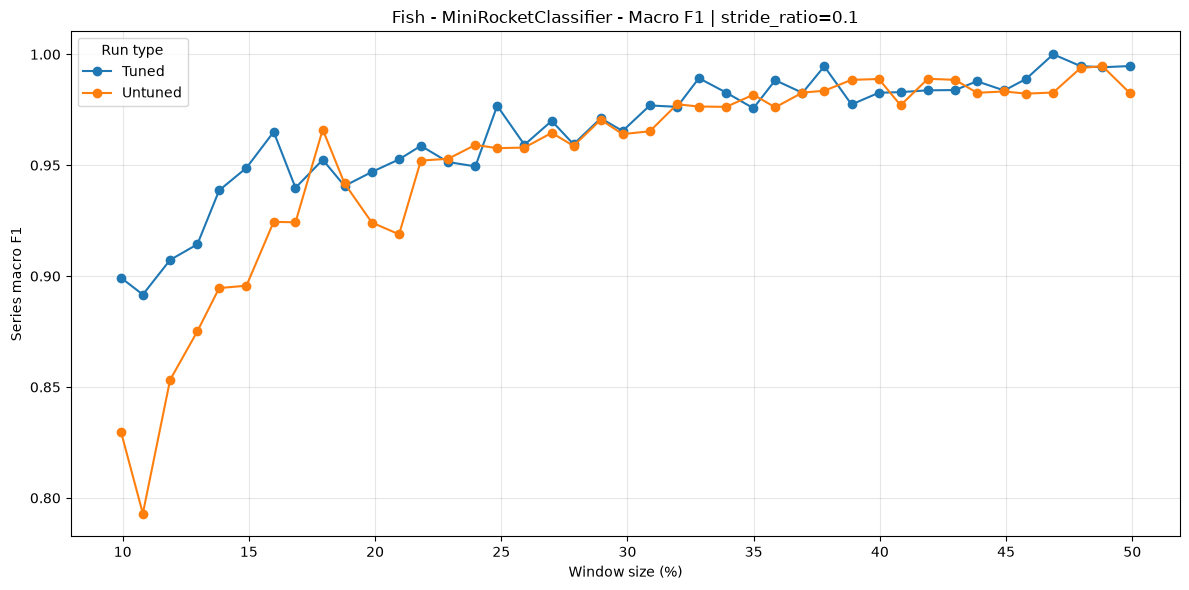

Saved: plots/Fish/MiniRocket/macro_f1_20_40/macro_f1_not_tuned_vs_tuned_stride_0p2.png


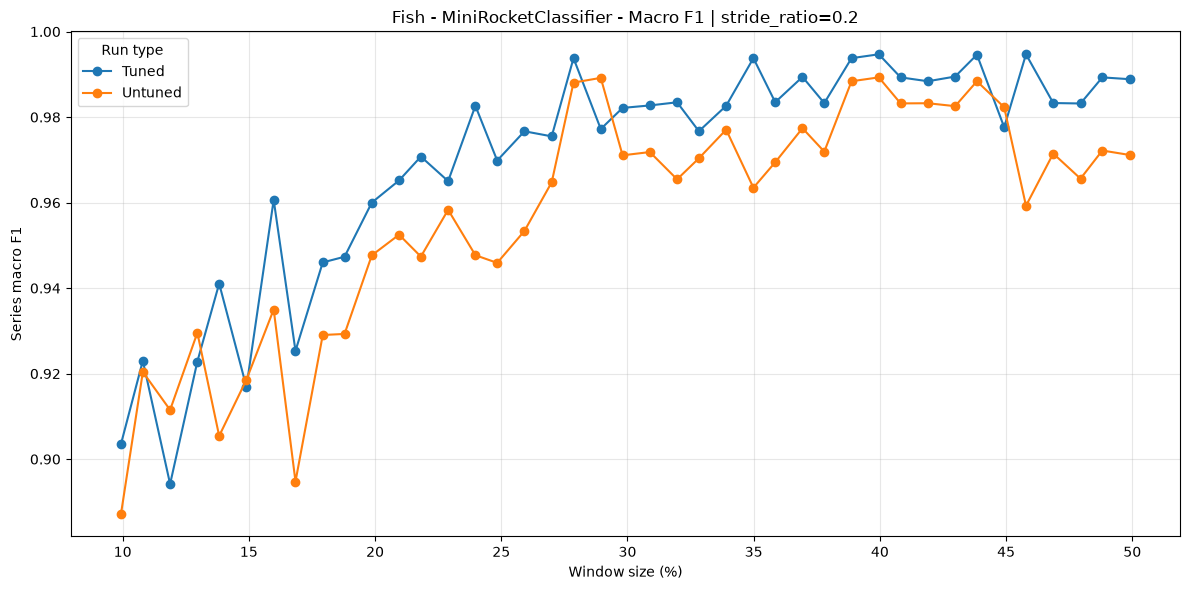

Saved: plots/Fish/MiniRocket/macro_f1_20_40/macro_f1_not_tuned_vs_tuned_stride_0p5.png


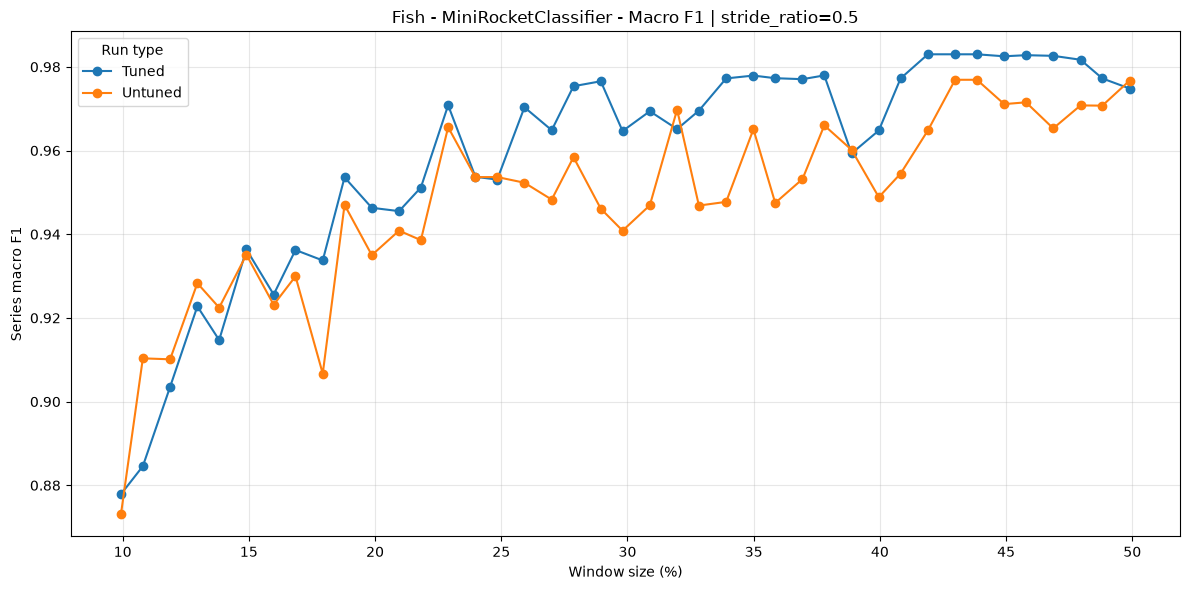

In [23]:
for stride_ratio, group in plot_df.groupby("stride_ratio"):
    fig, ax = plt.subplots(figsize=(12, 6))

    for run_type, run_group in group.groupby("run_type"):
        run_group = run_group.sort_values("window_percentage")
        ax.plot(
            run_group["window_percentage"] * 100,
            run_group["series_macro_f1"],
            marker="o",
            label=run_type,
        )

    ax.set_title(f"Fish - MiniRocketClassifier - Macro F1 | stride_ratio={stride_ratio}")
    ax.set_xlabel("Window size (%)")
    ax.set_ylabel("Series macro F1")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Run type")

    fig.tight_layout()

    output_file = PLOTS_DIR / f"macro_f1_not_tuned_vs_tuned_stride_{str(stride_ratio).replace('.', 'p')}.png"
    fig.savefig(output_file, dpi=300, bbox_inches="tight")

    print("Saved:", output_file)
    plt.show()


## 12. Plot: tuning improvement

This plot shows:

```text
delta = tuned_series_macro_f1 - not_tuned_series_macro_f1
```

Interpretation:

```text
delta > 0  improvement
delta = 0  no difference
delta < 0  decrease
```


Saved: plots/Fish/MiniRocket/macro_f1_20_40/macro_f1_delta_stride_0p1.png


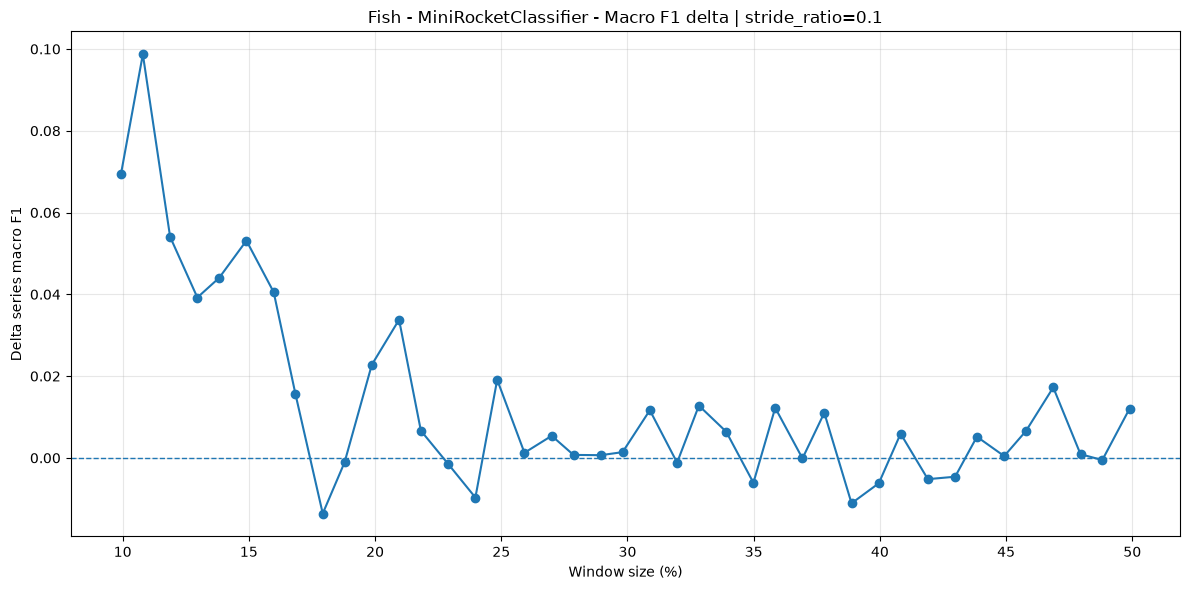

Saved: plots/Fish/MiniRocket/macro_f1_20_40/macro_f1_delta_stride_0p2.png


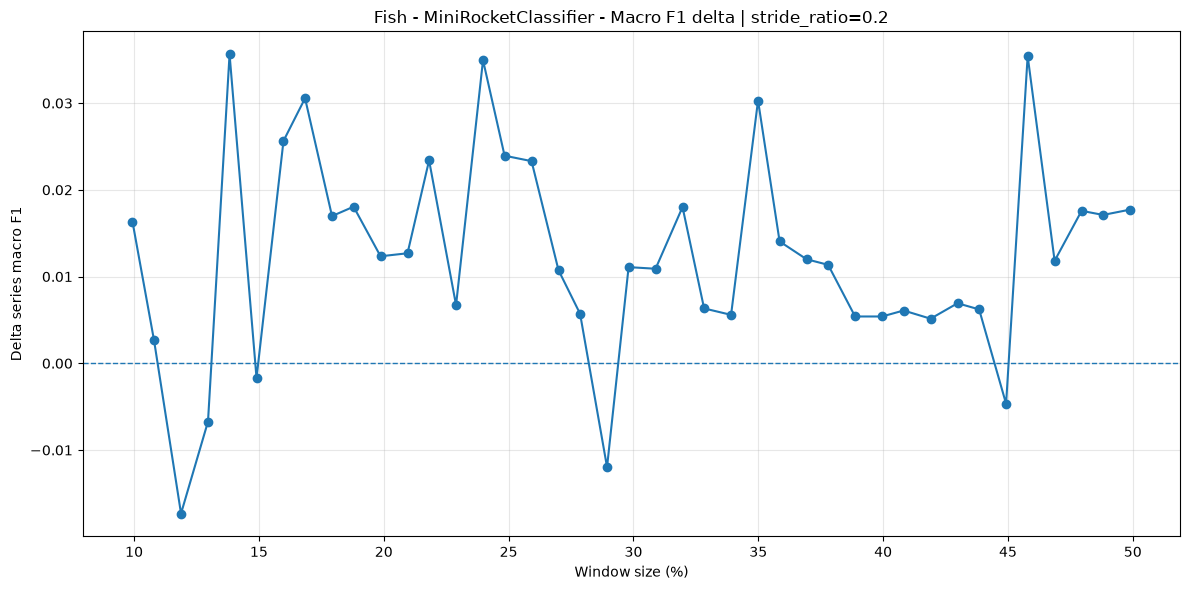

Saved: plots/Fish/MiniRocket/macro_f1_20_40/macro_f1_delta_stride_0p5.png


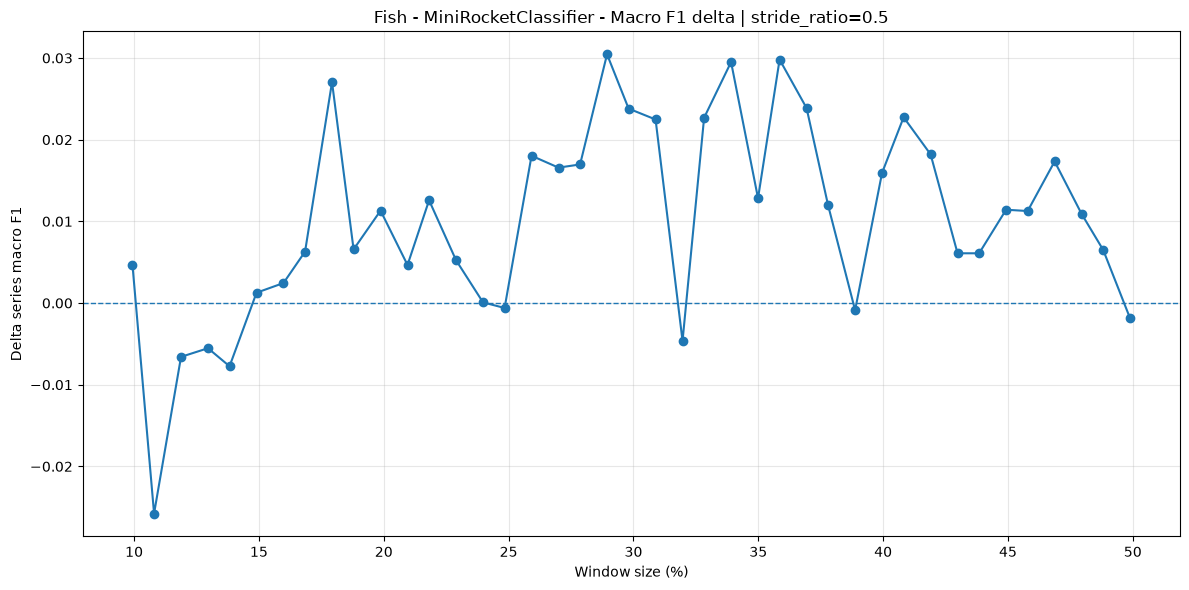

In [24]:
for stride_ratio, group in comparison.groupby("stride_ratio"):
    group = group.sort_values("window_percentage")

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        group["window_percentage"] * 100,
        group["delta_series_macro_f1"],
        marker="o",
    )

    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_title(f"Fish - MiniRocketClassifier - Macro F1 delta | stride_ratio={stride_ratio}")
    ax.set_xlabel("Window size (%)")
    ax.set_ylabel("Delta series macro F1")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    output_file = PLOTS_DIR / f"macro_f1_delta_stride_{str(stride_ratio).replace('.', 'p')}.png"
    fig.savefig(output_file, dpi=300, bbox_inches="tight")

    print("Saved:", output_file)
    plt.show()


,phase,total_time_sec,total_time_min,total_time_hour
0,Untuned experiment,2319.976923,38.666282,0.644438
1,Hyperparameter tuning,3576.929384,59.615490,0.993591
2,Tuned retraining,162.827081,2.713785,0.045230


,trial_file,n_trials,total_duration_sec
0,results/Fish/tuning/Fish/MiniRocket/per_config...,20,41.336465
1,results/Fish/tuning/Fish/MiniRocket/per_config...,20,40.078403
2,results/Fish/tuning/Fish/MiniRocket/per_config...,20,7.087437
3,results/Fish/tuning/Fish/MiniRocket/per_config...,20,55.953908
4,results/Fish/tuning/Fish/MiniRocket/per_config...,20,43.184291


Saved phase time summary to: results/Fish/MiniRocket/comparison_20_40/fish_minirocket_phase_total_times.csv
Saved tuning trial time summary to: results/Fish/MiniRocket/comparison_20_40/fish_minirocket_tuning_trial_total_times.csv
Saved: plots/Fish/MiniRocket/macro_f1_20_40/execution_time/total_execution_time_by_phase.png


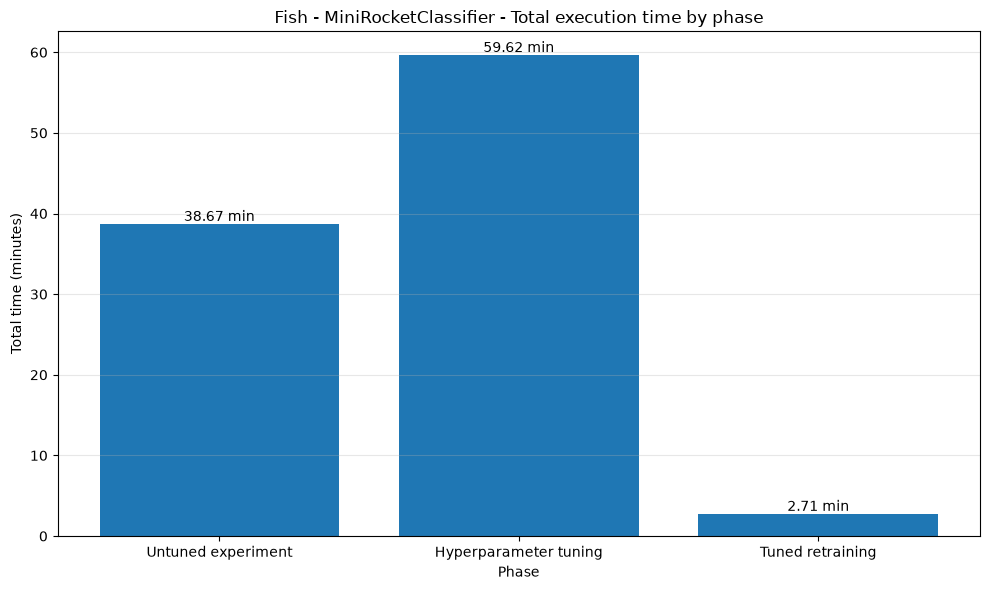

Saved: plots/Fish/MiniRocket/macro_f1_20_40/execution_time/untuned_fit_time_by_configuration.png


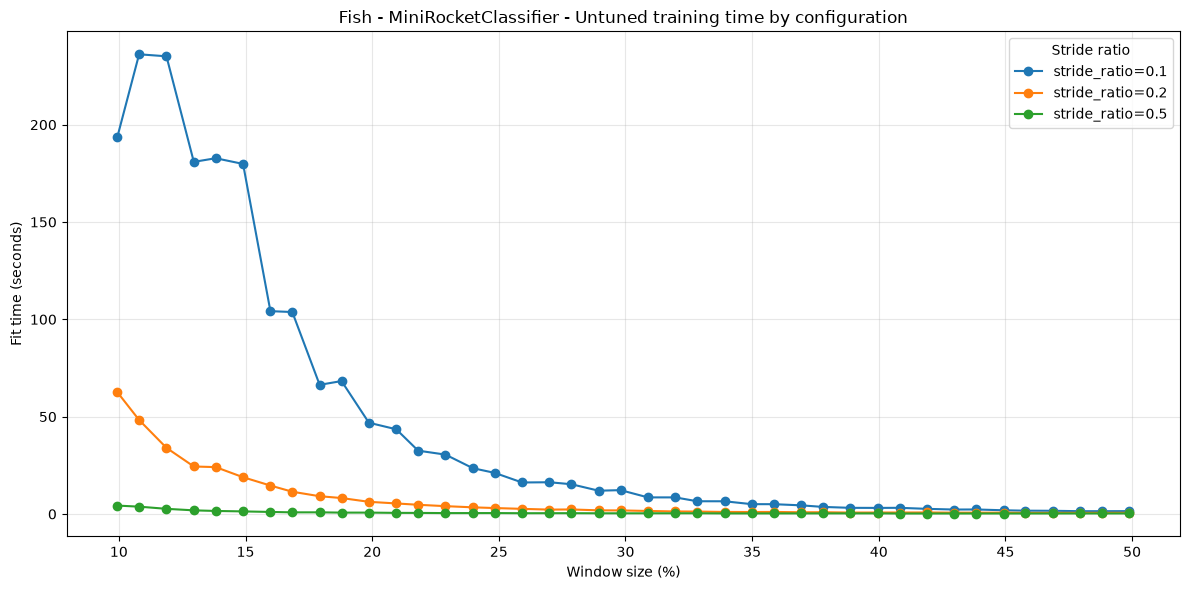

Saved: plots/Fish/MiniRocket/macro_f1_20_40/execution_time/tuned_fit_time_by_configuration.png


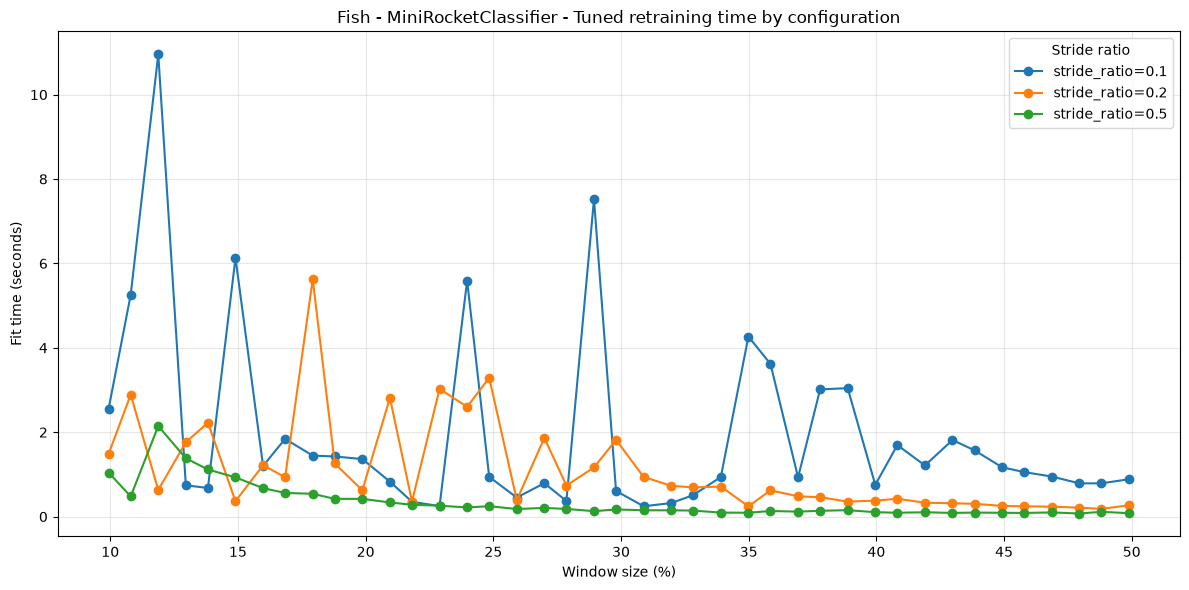

In [26]:
# ---------------------------------------------------------------------
# Final cell: total execution time and per-configuration training times
# ---------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

TIME_PLOTS_DIR = PLOTS_DIR / "execution_time"
TIME_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Reload data if needed
# ---------------------------------------------------------------------

if "not_tuned" not in globals():
    not_tuned_file = sorted(NOT_TUNED_DIR.glob("*.csv"))[-1]
    not_tuned = pd.read_csv(not_tuned_file)

if "tuned" not in globals():
    tuned_file = sorted(TUNED_DIR.glob("*.csv"))[-1]
    tuned = pd.read_csv(tuned_file)

not_tuned_ok = not_tuned[not_tuned["status"] == "ok"].copy()
tuned_ok = tuned[tuned["status"] == "ok"].copy()

# ---------------------------------------------------------------------
# 1. Total time of each phase
# ---------------------------------------------------------------------
# Untuned phase:
#   one full run with default hyperparameters.
#
# Tuning phase:
#   sum of all Optuna trial durations saved in the trials CSV files.
#
# Tuned retraining phase:
#   final rerun using the best hyperparameters for each window/stride config.
# ---------------------------------------------------------------------

untuned_total_time_sec = not_tuned_ok["total_time_sec"].sum()
tuned_retraining_total_time_sec = tuned_ok["total_time_sec"].sum()

# Read Optuna trial durations
trials_dir = TUNING_DIR / "trials"
trial_files = sorted(trials_dir.glob("*_trials.csv"))

if len(trial_files) == 0:
    raise FileNotFoundError(f"No Optuna trial CSV files found in: {trials_dir}")

tuning_total_time_sec = 0.0
trial_rows = []

for trial_file in trial_files:
    trials_df = pd.read_csv(trial_file)

    if "duration" not in trials_df.columns:
        raise ValueError(
            f"Column 'duration' not found in {trial_file}. "
            "Cannot compute total tuning time."
        )

    durations_sec = pd.to_timedelta(trials_df["duration"]).dt.total_seconds()
    file_total_sec = durations_sec.sum()

    tuning_total_time_sec += file_total_sec

    trial_rows.append({
        "trial_file": str(trial_file),
        "n_trials": len(trials_df),
        "total_duration_sec": file_total_sec,
    })

trial_time_summary = pd.DataFrame(trial_rows)

phase_time_summary = pd.DataFrame([
    {
        "phase": "Untuned experiment",
        "total_time_sec": untuned_total_time_sec,
        "total_time_min": untuned_total_time_sec / 60,
        "total_time_hour": untuned_total_time_sec / 3600,
    },
    {
        "phase": "Hyperparameter tuning",
        "total_time_sec": tuning_total_time_sec,
        "total_time_min": tuning_total_time_sec / 60,
        "total_time_hour": tuning_total_time_sec / 3600,
    },
    {
        "phase": "Tuned retraining",
        "total_time_sec": tuned_retraining_total_time_sec,
        "total_time_min": tuned_retraining_total_time_sec / 60,
        "total_time_hour": tuned_retraining_total_time_sec / 3600,
    },
])

display(phase_time_summary)
display(trial_time_summary.head())

phase_time_file = COMPARISON_DIR / "fish_minirocket_phase_total_times.csv"
trial_time_file = COMPARISON_DIR / "fish_minirocket_tuning_trial_total_times.csv"

phase_time_summary.to_csv(phase_time_file, index=False)
trial_time_summary.to_csv(trial_time_file, index=False)

print("Saved phase time summary to:", phase_time_file)
print("Saved tuning trial time summary to:", trial_time_file)

# Plot total phase times
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    phase_time_summary["phase"],
    phase_time_summary["total_time_min"],
)

ax.set_title("Fish - MiniRocketClassifier - Total execution time by phase")
ax.set_xlabel("Phase")
ax.set_ylabel("Total time (minutes)")
ax.grid(axis="y", alpha=0.3)

for index, row in phase_time_summary.iterrows():
    ax.text(
        index,
        row["total_time_min"],
        f'{row["total_time_min"]:.2f} min',
        ha="center",
        va="bottom",
    )

fig.tight_layout()

output_file = TIME_PLOTS_DIR / "total_execution_time_by_phase.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")

print("Saved:", output_file)
plt.show()

# ---------------------------------------------------------------------
# 2. Per-configuration training time: untuned
# ---------------------------------------------------------------------

untuned_plot = not_tuned_ok.sort_values(["stride_ratio", "window_percentage"]).copy()

fig, ax = plt.subplots(figsize=(12, 6))

for stride_ratio, group in untuned_plot.groupby("stride_ratio"):
    group = group.sort_values("window_percentage")

    ax.plot(
        group["window_percentage"] * 100,
        group["fit_time_sec"],
        marker="o",
        label=f"stride_ratio={stride_ratio}",
    )

ax.set_title("Fish - MiniRocketClassifier - Untuned training time by configuration")
ax.set_xlabel("Window size (%)")
ax.set_ylabel("Fit time (seconds)")
ax.grid(True, alpha=0.3)
ax.legend(title="Stride ratio")

fig.tight_layout()

output_file = TIME_PLOTS_DIR / "untuned_fit_time_by_configuration.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")

print("Saved:", output_file)
plt.show()

# ---------------------------------------------------------------------
# 3. Per-configuration training time: tuned retraining
# ---------------------------------------------------------------------

tuned_plot = tuned_ok.sort_values(["stride_ratio", "window_percentage"]).copy()

fig, ax = plt.subplots(figsize=(12, 6))

for stride_ratio, group in tuned_plot.groupby("stride_ratio"):
    group = group.sort_values("window_percentage")

    ax.plot(
        group["window_percentage"] * 100,
        group["fit_time_sec"],
        marker="o",
        label=f"stride_ratio={stride_ratio}",
    )

ax.set_title("Fish - MiniRocketClassifier - Tuned retraining time by configuration")
ax.set_xlabel("Window size (%)")
ax.set_ylabel("Fit time (seconds)")
ax.grid(True, alpha=0.3)
ax.legend(title="Stride ratio")

fig.tight_layout()

output_file = TIME_PLOTS_DIR / "tuned_fit_time_by_configuration.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")

print("Saved:", output_file)
plt.show()